In [1]:
import pandas as pd
import mysql.connector

In [2]:
conn = mysql.connector.connect(
    host='127.0.0.1',         #using ip for the localhost
    user='root',              #using 'root' for default username
    password='data602',       #using mysql server password
    database='data602',       #using database name 'data602'
    port=3306                 #using default MySQL port
)

In [3]:
#defining the query that selects all the data from the mysql database that have the state code '36' (NY state)
#and have the county codes '005' (Bronx), '047' (Kings), '061' (New York), '081' (Queens), '085' (Richmond)
query = "SELECT * FROM dailyaqi WHERE State_Code = '36' AND County_Code IN ('005', '047', '061', '081', '085');"
df = pd.read_sql(query, conn) #running the query using the mysql connection and saving the data in a dataframe
conn.close()
print(df.head())

C:\Users\Khandker\AppData\Local\Temp\ipykernel_27540\3753488430.py:4: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn) #running the query using the mysql connection and saving the data in a dataframe


  State_Name County_Name State_Code County_Code    Obs_Date  AQI Category  \
0   New York       Bronx         36         005  1980-01-01   40     Good   
1   New York       Bronx         36         005  1980-01-02   28     Good   
2   New York       Bronx         36         005  1980-01-03   29     Good   
3   New York       Bronx         36         005  1980-01-04   31     Good   
4   New York       Bronx         36         005  1980-01-05   29     Good   

  Defining_Parameter Defining_Site  No_of_Sites_Reporting  
0                NO2   36-005-0003                      1  
1                NO2   36-005-0003                      1  
2                NO2   36-005-0003                      1  
3                NO2   36-005-0003                      1  
4                NO2   36-005-0003                      1  


In [4]:
df['Obs_Date'] = pd.to_datetime(df['Obs_Date'])

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77083 entries, 0 to 77082
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   State_Name             77083 non-null  object        
 1   County_Name            77083 non-null  object        
 2   State_Code             77083 non-null  object        
 3   County_Code            77083 non-null  object        
 4   Obs_Date               77083 non-null  datetime64[ns]
 5   AQI                    77083 non-null  int64         
 6   Category               77083 non-null  object        
 7   Defining_Parameter     77083 non-null  object        
 8   Defining_Site          77083 non-null  object        
 9   No_of_Sites_Reporting  77083 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(7)
memory usage: 5.9+ MB
None


In [6]:
print(df['AQI'].describe())

count    77083.000000
mean        51.806391
std         29.616273
min          0.000000
25%         34.000000
50%         47.000000
75%         62.000000
max        279.000000
Name: AQI, dtype: float64


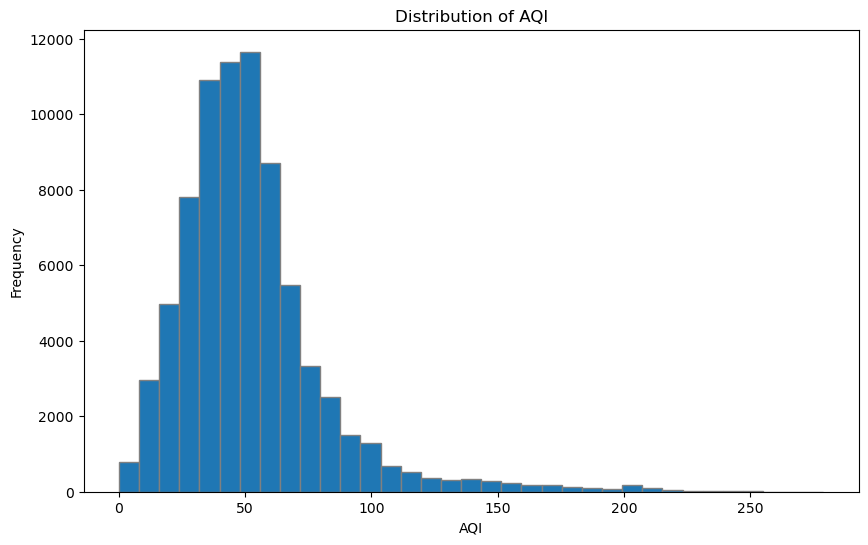

In [7]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(df['AQI'], bins=35, edgecolor='grey')
plt.title('Distribution of AQI')
plt.xlabel('AQI')
plt.ylabel('Frequency')
plt.show()

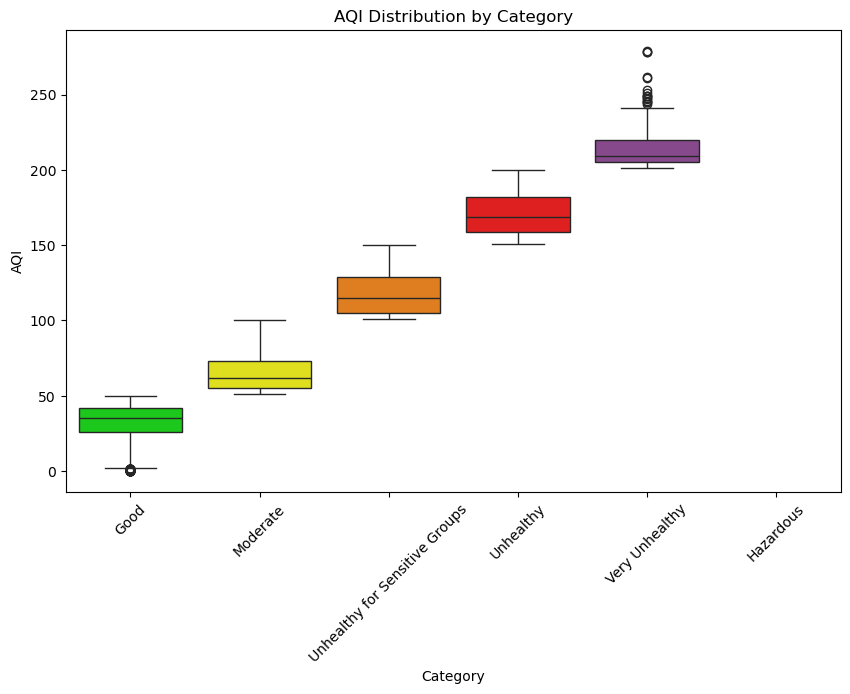

In [8]:
import seaborn as sns
cust_color_by_cat = {
    'Good': '#00E400',                     
    'Moderate': '#FFFF00',               
    'Unhealthy for Sensitive Groups': '#FF7E00',  
    'Unhealthy': '#FF0000',                
    'Very Unhealthy': '#8F3F97',         
    'Hazardous': '#7E0023'                
}
plt.figure(figsize=(10,6))
sns.boxplot(x= 'Category', y= 'AQI', data= df, hue= 'Category', palette= cust_color_by_cat, order= list(cust_color_by_cat.keys()))
plt.title('AQI Distribution by Category')
plt.xticks(rotation=45)
plt.show()

# **Research Question 1**

# Yearly Trend of Average AQI: 
A line plot below illustrates how the average AQI has changed over the year in NYC. In general, the line shows a downward trend with some occasional spikes and falls. In this timespan, the highest average AQI in NYC was recorded in 1985, and the lowest was recorded in 1992 (the average AQI for 2025 seems lower, but that is due to incomplete year data). In recent years, the air quality index has been consistently below 50, which is further confirmed in the IQAIR’s analysis, found here: https://www.iqair.com/us/usa/new-york/new-york.

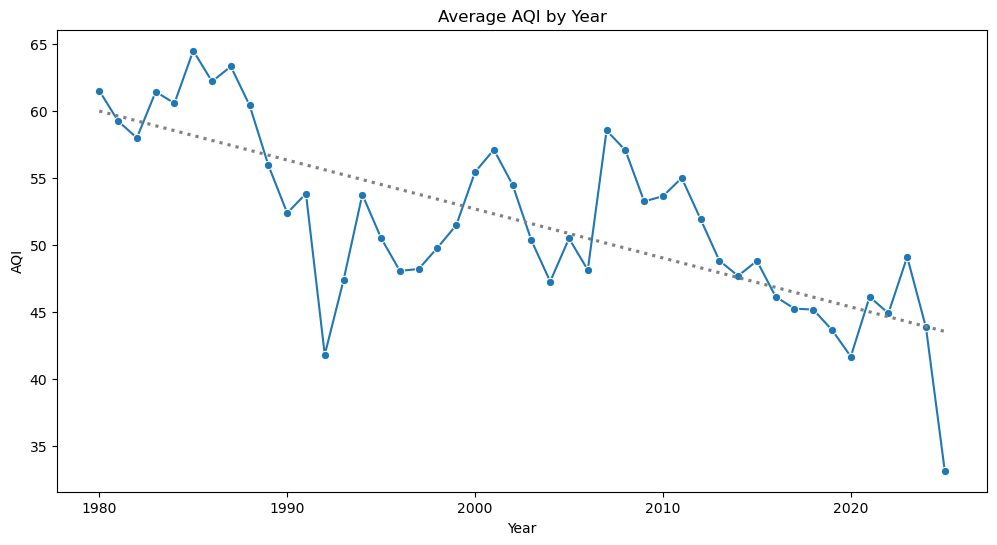

In [9]:
#Yearly trend of average AQI
df['Year'] = df['Obs_Date'].dt.year
avg_aqi_year = df.groupby('Year')['AQI'].mean().reset_index()
plt.figure(figsize=(12,6))
sns.lineplot(x='Year', y='AQI', data=avg_aqi_year, marker='o')
sns.regplot(x='Year', y='AQI', data=avg_aqi_year, scatter=False, ci=None, color='grey', line_kws={"linestyle": ":"})
plt.title('Average AQI by Year')
plt.show()

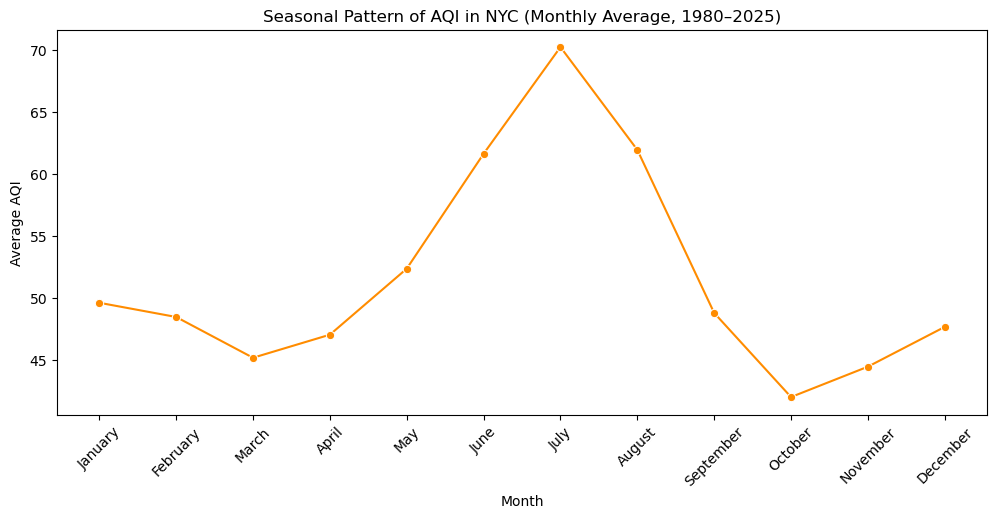

In [10]:
#Seasonal pattern of AQI by month
df['Obs_Date'] = pd.to_datetime(df['Obs_Date']) 
df['Year'] = df['Obs_Date'].dt.year 
df['Month'] = df['Obs_Date'].dt.month_name() 

monthly_pattern = ( df.groupby('Month')['AQI'].mean()
                   .reindex([ 'January','February','March','April','May','June', 'July','August','September','October','November','December' ])) 
plt.figure(figsize=(12,5)) 
sns.lineplot(x=monthly_pattern.index, y=monthly_pattern.values, marker='o', color='darkorange') 
plt.title('Seasonal Pattern of AQI in NYC (Monthly Average, 1980–2025)') 
plt.xlabel('Month') 
plt.ylabel('Average AQI') 
plt.xticks(rotation=45) 
plt.show()

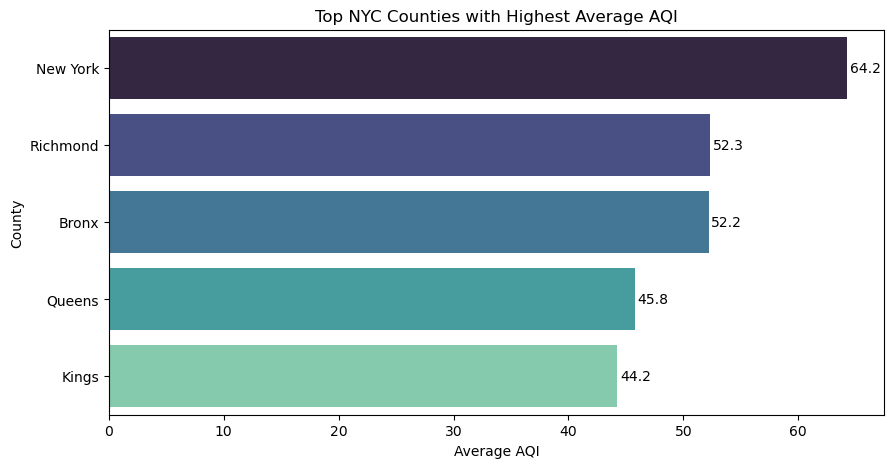

In [11]:
#County comparison
top_counties = df.groupby('County_Name')['AQI'].mean().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
ax = sns.barplot(x=top_counties.values, y=top_counties.index, palette='mako', hue=top_counties.index, legend=False)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', padding=2)
plt.title('Top NYC Counties with Highest Average AQI')
plt.xlabel('Average AQI')
plt.ylabel('County')
plt.show()

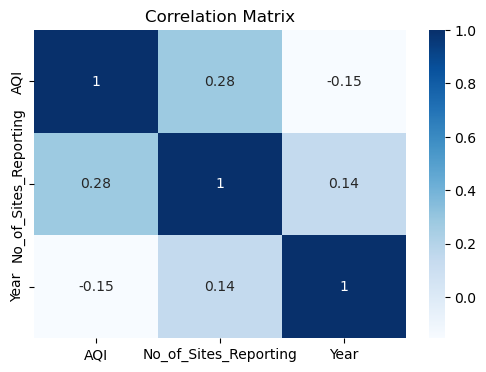

                            AQI  No_of_Sites_Reporting      Year
AQI                    1.000000               0.278485 -0.154568
No_of_Sites_Reporting  0.278485               1.000000  0.141975
Year                  -0.154568               0.141975  1.000000


In [12]:
#Correlation matrix for the numerical features
numeric_df = df.select_dtypes(include='number')
plt.figure(figsize=(6,4))
sns.heatmap(numeric_df.corr(), annot=True, cmap='Blues')
plt.title('Correlation Matrix')
plt.show()
print(numeric_df.corr())

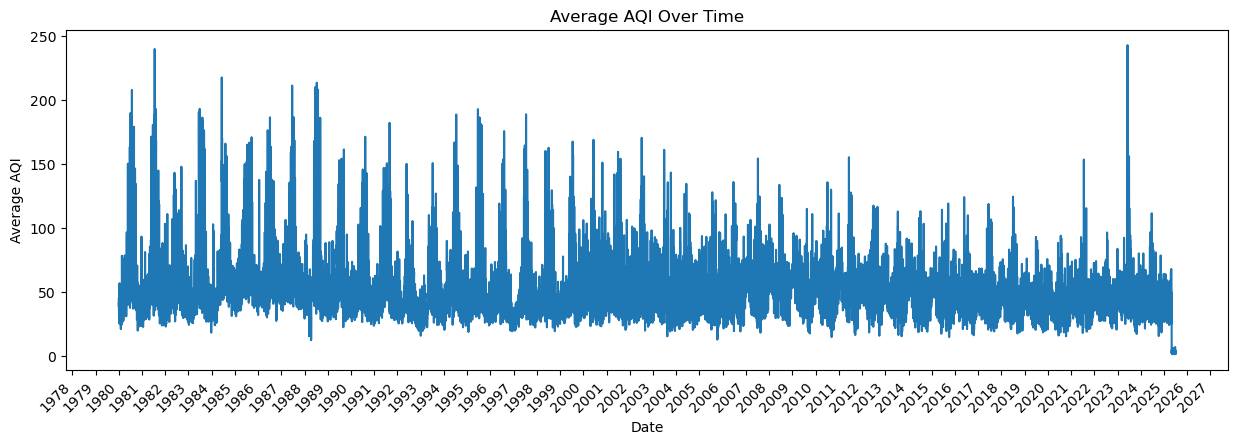

In [13]:
#Time series trend (overall)
import matplotlib.dates as mdates
plt.figure(figsize=(15,5))
df.groupby('Obs_Date')['AQI'].mean().plot()
plt.title('Average AQI Over Time')
plt.xlabel('Date')
plt.ylabel('Average AQI')
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.show()

In [14]:
df.head()

,State_Name,County_Name,State_Code,County_Code,Obs_Date,AQI,Category,Defining_Parameter,Defining_Site,No_of_Sites_Reporting,Year,Month
0,New York,Bronx,36,005,1980-01-01,40,Good,NO2,36-005-0003,1,1980,January
1,New York,Bronx,36,005,1980-01-02,28,Good,NO2,36-005-0003,1,1980,January
2,New York,Bronx,36,005,1980-01-03,29,Good,NO2,36-005-0003,1,1980,January
3,New York,Bronx,36,005,1980-01-04,31,Good,NO2,36-005-0003,1,1980,January
4,New York,Bronx,36,005,1980-01-05,29,Good,NO2,36-005-0003,1,1980,January


# **Research Question 2**

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


#Convert the data to datetime format and sort
df['Obs_Date'] = pd.to_datetime(df['Obs_Date'])
df = df.sort_values('Obs_Date')

#Extract the AQI column
AQI_data = df[['AQI']].values

#Scale the AQI data
scaler = MinMaxScaler(feature_range=(0,1))
AQI_data_scaled = scaler.fit_transform(AQI_data)

#Create sequences for LSTM
def create_sequences(AQI_data_scaled, time_steps=30):
    X, y = [], []
    for i in range(time_steps, len(AQI_data)):
        X.append(AQI_data_scaled[i-time_steps:i, 0])
        y.append(AQI_data_scaled[i, 0])
    return np.array(X), np.array(y)

X, y = create_sequences(AQI_data_scaled, 30)

#Reshape for LSTM
X = X.reshape((X.shape[0], X.shape[1], 1))

#Split for train and test dataset
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

#Build LSTM model
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(X_train.shape[1], 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

#Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=10, validation_split=0.1, verbose=1)

#Forecast and inverse scale
y_pred = model.predict(X_test)
y_pred_actual = scaler.inverse_transform(y_pred.reshape(-1,1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

#Model evaluation
print("Model Evaluation:")
mae = mean_absolute_error(y_test_actual, y_pred_actual)
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred_actual))
mask = y_test_actual != 0
mape = np.mean(np.abs((y_test_actual[mask] - y_pred_actual[mask]) / y_test_actual[mask])) * 100
r2 = r2_score(y_test_actual, y_pred_actual)
print(f"MAE  = {mae:.2f}")
print(f"RMSE = {rmse:.2f}")
print(f"MAPE = {mape:.2f}%")
print(f"R² Score = {r2:.4f}")

Epoch 1/20


E:\Anaconda\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5548/5548 ━━━━━━━━━━━━━━━━━━━━ 43s 7ms/step - loss: 0.0101 - val_loss: 0.0021
Epoch 2/20
5548/5548 ━━━━━━━━━━━━━━━━━━━━ 43s 8ms/step - loss: 0.0097 - val_loss: 0.0022
Epoch 3/20
5548/5548 ━━━━━━━━━━━━━━━━━━━━ 43s 8ms/step - loss: 0.0096 - val_loss: 0.0025
Epoch 4/20
5548/5548 ━━━━━━━━━━━━━━━━━━━━ 41s 7ms/step - loss: 0.0095 - val_loss: 0.0020
Epoch 5/20
5548/5548 ━━━━━━━━━━━━━━━━━━━━ 41s 7ms/step - loss: 0.0095 - val_loss: 0.0020
Epoch 6/20
5548/5548 ━━━━━━━━━━━━━━━━━━━━ 42s 8ms/step - loss: 0.0094 - val_loss: 0.0023
Epoch 7/20
5548/5548 ━━━━━━━━━━━━━━━━━━━━ 42s 7ms/step - loss: 0.0094 - val_loss: 0.0020
Epoch 8/20
5548/5548 ━━━━━━━━━━━━━━━━━━━━ 42s 8ms/step - loss: 0.0094 - val_loss: 0.0020
Epoch 9/20
5548/5548 ━━━━━━━━━━━━━━━━━━━━ 42s 8ms/step - loss: 0.0094 - val_loss: 0.0020
Epoch 10/20
5548/5548 ━━━━━━━━━━━━━━━━━━━━ 41s 7ms/step - loss: 0.0094 - val_loss: 0.0021
Epoch 11/20
5548/5548 ━━━━━━━━━━━━━━━━━━━━ 41s 7ms/step - loss: 0.0094 - val_loss: 0.0022
Epoch 12/20
5548/5548 ━━━━━━━━

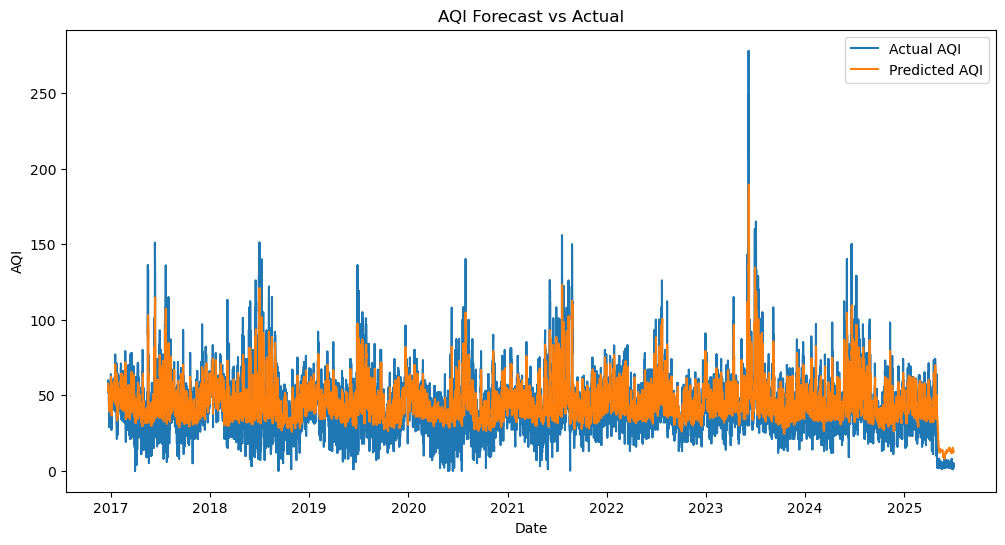

In [22]:
#Plot predictions vs actuals
plt.figure(figsize=(12,6))
plt.plot(df['Obs_Date'][-len(y_test_actual):], y_test_actual, label='Actual AQI')
plt.plot(df['Obs_Date'][-len(y_test_actual):], y_pred_actual, label='Predicted AQI')
plt.title('AQI Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.legend()
plt.show()


# **Research Question 3**

In [31]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

#df is already loaded
df['Obs_Date'] = pd.to_datetime(df['Obs_Date'])
df['Month'] = df['Obs_Date'].dt.month
df['Year'] = df['Obs_Date'].dt.year

#Feature selection
features = ['County_Code', 'Month', 'Year', 'No_of_Sites_Reporting', 'Defining_Parameter'] 

#Encode categorical features
df['County_Code'] = df['County_Code'].astype('category')
df['Defining_Parameter'] = df['Defining_Parameter'].astype('category')

X = pd.get_dummies(df[features], columns=['County_Code', 'Defining_Parameter'])

#Encode target
le = LabelEncoder()
y = le.fit_transform(df['Category'])

#Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#Scale features for algorithms that require it i.e. SVC, KNN, Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Define classifiers
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=500, class_weight='balanced', multi_class='multinomial'),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, class_weight='balanced'),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVC": SVC(kernel='rbf', class_weight='balanced', probability=True)
}

#Train and evaluate
for name, clf in classifiers.items():
    print(f"\n--- {name} ---")
    
    #Choose scaled data for algorithms that need it
    if name in ["Logistic Regression", "SVC", "KNN"]:
        clf.fit(X_train_scaled, y_train)
        y_pred = clf.predict(X_test_scaled)
    else:
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
    
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))



--- Logistic Regression ---


E:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Classification Report:
                                precision    recall  f1-score   support

                          Good       0.73      0.50      0.60      8436
                      Moderate       0.61      0.59      0.60      6123
                     Unhealthy       0.04      0.23      0.06       200
Unhealthy for Sensitive Groups       0.12      0.28      0.17       587
                Very Unhealthy       0.06      0.86      0.11        71

                      accuracy                           0.53     15417
                     macro avg       0.31      0.49      0.31     15417
                  weighted avg       0.65      0.53      0.57     15417

Confusion Matrix:
[[4251 2209  957  476  543]
 [1405 3638  189  712  179]
 [  13   11   46   25  105]
 [ 114   82   88  167  136]
 [   1    1    6    2   61]]

--- Random Forest ---
Classification Report:
                                precision    recall  f1-score   support

                          Good       0.80      0